5. WAP to train and evaluate a convolutional neural network using Keras Library to classify MNIST fashion dataset. Demonstrate the effect of filter size, regularization, batch size and optimization algorithm on model performance.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
# Load and preprocess data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [3]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    shear_range=0.08,
    horizontal_flip=False
)
datagen.fit(x_train)

In [4]:
# Enhanced Architecture with Residual Connections
def conv_block(l, filters, use_residual=False):
    l = Conv2D(filters, (3,3), padding='same')(l)
    l = BatchNormalization()(l)
    l = tf.keras.layers.Activation('relu')(l)
    l = Conv2D(filters, (3,3), padding='same')(l)
    l = BatchNormalization()(l)
    if use_residual:
        shortcut = Conv2D(filters, (1,1), padding='same')(l)
        l = tf.keras.layers.add([l, shortcut])
    l = tf.keras.layers.Activation('relu')(l)
    return l

In [5]:
inputs = tf.keras.Input(shape=(28,28,1))
x = conv_block(inputs, 64)
x = MaxPooling2D(2,2)(x)
x = Dropout(0.3)(x)

x = conv_block(x, 128, use_residual=True)
x = MaxPooling2D(2,2)(x)
x = Dropout(0.3)(x)

x = conv_block(x, 256)
x = GlobalAveragePooling2D()(x)

x = Dense(512)(x)
x = BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)
x = Dropout(0.6)(x)
outputs = Dense(10, activation='softmax')(x)


In [6]:
model = tf.keras.Model(inputs, outputs)

In [7]:
# Custom Learning Rate Schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.9
)
optimizer = Adam(learning_rate=lr_schedule)


In [8]:
# Add Label Smoothing
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])


In [9]:
# Enhanced Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=25, mode='max')
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True,
                            monitor='val_accuracy', mode='max')

In [ ]:
# Train model
history = model.fit(datagen.flow(x_train, y_train, batch_size=256),
                    steps_per_epoch=len(x_train)//256,
                    epochs=150,
                    validation_data=(x_test, y_test),
                    callbacks=[early_stop, checkpoint])

Epoch 1/150


c:\Users\harsh\.conda\envs\Projects\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6474 - loss: 1.3758

234/234 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.6478 - loss: 1.3747 - val_accuracy: 0.1189 - val_loss: 2.9445
Epoch 2/150
  1/234 ━━━━━━━━━━━━━━━━━━━━ 5:03 1s/step - accuracy: 0.8320 - loss: 0.9458

c:\Users\harsh\.conda\envs\Projects\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

234/234 ━━━━━━━━━━━━━━━━━━━━ 230s 982ms/step - accuracy: 0.9207 - loss: 0.6968 - val_accuracy: 0.9174 - val_loss: 0.6884
Epoch 28/150
  1/234 ━━━━━━━━━━━━━━━━━━━━ 4:15 1s/step - accuracy: 0.9414 - loss: 0.6524

234/234 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9414 - loss: 0.6524 - val_accuracy: 0.9180 - val_loss: 0.6866
Epoch 29/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.9247 - loss: 0.6906

234/234 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.9247 - loss: 0.6906 - val_accuracy: 0.9232 - val_loss: 0.6761
Epoch 30/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9102 - loss: 0.6803 - val_accuracy: 0.9226 - val_loss: 0.6768
Epoch 31/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 987ms/step - accuracy: 0.9264 - loss: 0.6870

234/234 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.9264 - loss: 0.6871 - val_accuracy: 0.9285 - val_loss: 0.6712
Epoch 32/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9414 - loss: 0.6633 - val_accuracy: 0.9259 - val_loss: 0.6744
Epoch 33/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.9277 - loss: 0.6834 - val_accuracy: 0.9260 - val_loss: 0.6679
Epoch 34/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9141 - loss: 0.6858 - val_accuracy: 0.9265 - val_loss: 0.6687
Epoch 35/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9290 - loss: 0.6789 - val_accuracy: 0.9118 - val_loss: 0.6986
Epoch 36/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9336 - loss: 0.6707 - val_accuracy: 0.9138 - val_loss: 0.6935
Epoch 37/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.9282 - loss: 0.6794 - val_accuracy: 0.9065 - val_loss: 0.7062
Epoch 38/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9492 - loss: 0.6418 - va

234/234 ━━━━━━━━━━━━━━━━━━━━ 338s 1s/step - accuracy: 0.9388 - loss: 0.6554 - val_accuracy: 0.9314 - val_loss: 0.6635
Epoch 52/150
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.9141 - loss: 0.6839 - val_accuracy: 0.9311 - val_loss: 0.6644
Epoch 53/150
191/234 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.9392 - loss: 0.6524


Test accuracy: 0.9314


NameError: name 'history' is not defined

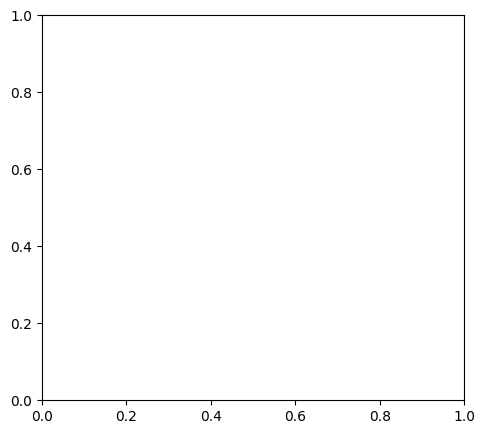

In [10]:
# Load best model and evaluate
model.load_weights('best_model.h5')
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'\nTest accuracy: {test_acc:.4f}')

# Plot training history
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(linestyle='--', linewidth=0.5)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()